In [30]:
import pandas as pd
import sys
import importlib
import numpy as np

In [67]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [68]:
sys.path.append("../src")
import modeling as mod
import visualization as visual
import grid_search as gs
import modeling_utils as utils

importlib.reload(mod)
importlib.reload(visual)
importlib.reload(gs)
importlib.reload(utils)

<module 'modeling_utils' from '/home/abril/UdeSA/ML/TP_Final_ML/notebooks/../src/modeling_utils.py'>

In [33]:
X_train_pp = pd.read_csv("../data/X_train_pp.csv")
X_val_pp = pd.read_csv("../data/X_val_pp.csv")

# Datasests pre one-hot for cross validation
X_train = pd.read_csv("../data/X_train.csv")
X_val = pd.read_csv("../data/X_val.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_val = pd.read_csv("../data/y_val.csv").squeeze()

<h1 style="
    background-color: #d0ebff; 
    color: #1a1a1a; 
    display: inline-block; 
    padding: 10px 18px; 
    border-radius: 10px;
    font-size: 32px;
">
Predictive Modeling
</h1>

En esta sección se entrenan y evalúan distintos modelos de regresión para estimar el precio de SUVs en dólares. Primero se utiliza una regresión lineal como modelo base, y luego se comparará su desempeño contra modelos más complejos.

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Baseline Model: Linear Regression
</h3>

La regresión lineal se utiliza como modelo base porque permite obtener una primera referencia del error predictivo. Este modelo asume una relación lineal entre las variables de entrada y el precio, por lo que sirve como punto de comparación para evaluar si modelos más complejos logran mejorar la predicción.

La métrica principal utilizada será el MSE, que mide el promedio de los errores cuadráticos entre el precio real y el precio predicho.

In [34]:
linear_model, linear_metrics, linear_predictions = mod.train_linear_regression(X_train_pp, y_train, X_val_pp, y_val)

In [35]:
X_train_pp.isna().sum()[X_train_pp.isna().sum() > 0].sort_values(ascending=False)

Cilindrada    18
dtype: int64

In [36]:
X_val_pp.isna().sum()[X_val_pp.isna().sum() > 0].sort_values(ascending=False)

Cilindrada    4
dtype: int64

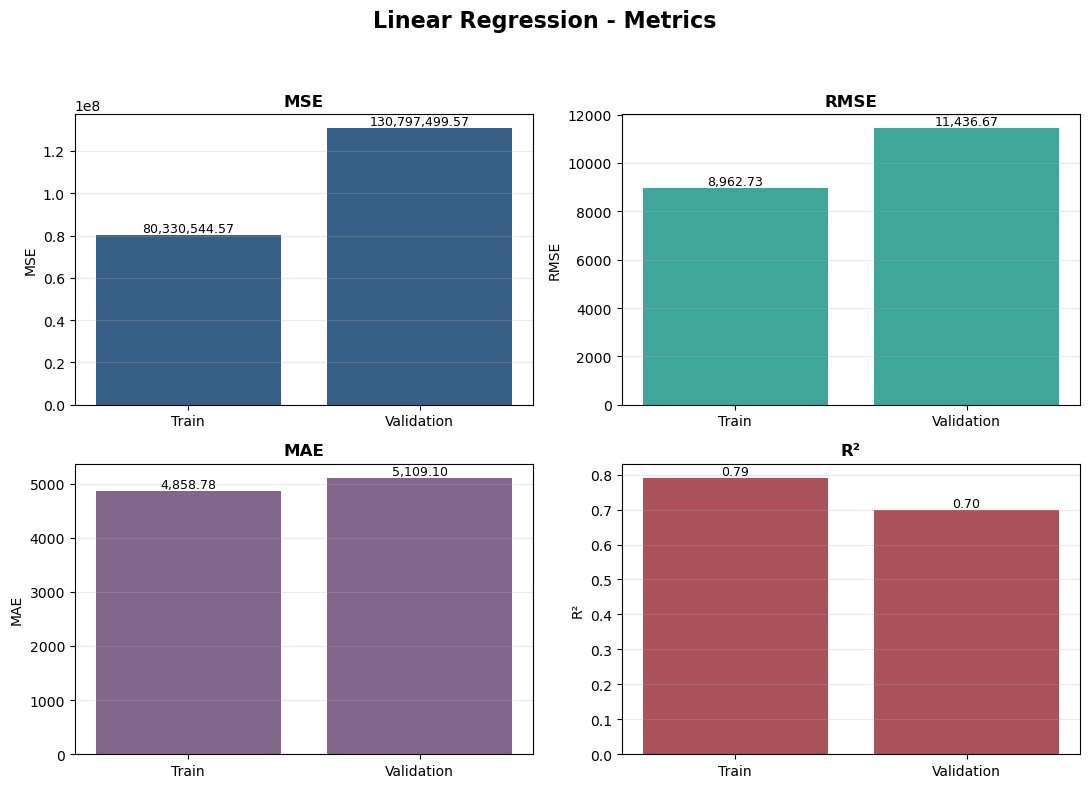

In [37]:
visual.plot_regression_metrics(
    linear_metrics,
    model_name="Linear Regression"
)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Ridge Regression
</h3>

La regresión Ridge es una extensión de la regresión lineal que incorpora regularización L2. Este término de penalización evita que los coeficientes del modelo tomen valores excesivamente grandes, reduciendo así el riesgo de sobreajuste.

En este trabajo resulta especialmente útil debido a la aplicación de One-Hot Encoding sobre variables categóricas como la marca, el modelo, el color y el tipo de combustible, lo que incrementa considerablemente el número de variables predictoras y puede generar correlaciones entre ellas.

Al igual que en la regresión lineal, el desempeño del modelo se evaluará utilizando como métrica principal el Error Cuadrático Medio (MSE), complementando el análisis con RMSE, MAE y R².

In [38]:
#VER ESTO TEMA PREROCESAMIENTO
ALPHAS = (0.001, 0.01, 0.1, 1, 10, 100, 500, 1000)

best_ridge_alpha, ridge_cv_results = gs.find_best_alpha_ridge(
    X_train_pp, y_train, alphas=ALPHAS, cv=5,
)

print(f"Best Ridge alpha: {best_ridge_alpha}")
ridge_cv_results  # tabla con mean_cv_mse y std_cv_mse por alpha

Best Ridge alpha: 10.0


,alpha,mean_cv_mse,std_cv_mse
0,10.000,8.773792e+07,2.119111e+07
1,1.000,8.774113e+07,2.115400e+07
2,0.100,8.774153e+07,2.115027e+07
3,0.010,8.774157e+07,2.114989e+07
4,0.001,8.774158e+07,2.114986e+07
5,100.000,8.777674e+07,2.153963e+07
6,500.000,8.871892e+07,2.279776e+07
7,1000.000,9.053380e+07,2.398850e+07


In [39]:
ridge_model, ridge_metrics, ridge_predictions = mod.train_ridge_regression(
    X_train_pp, y_train, X_val_pp, y_val, alpha=best_ridge_alpha,
)

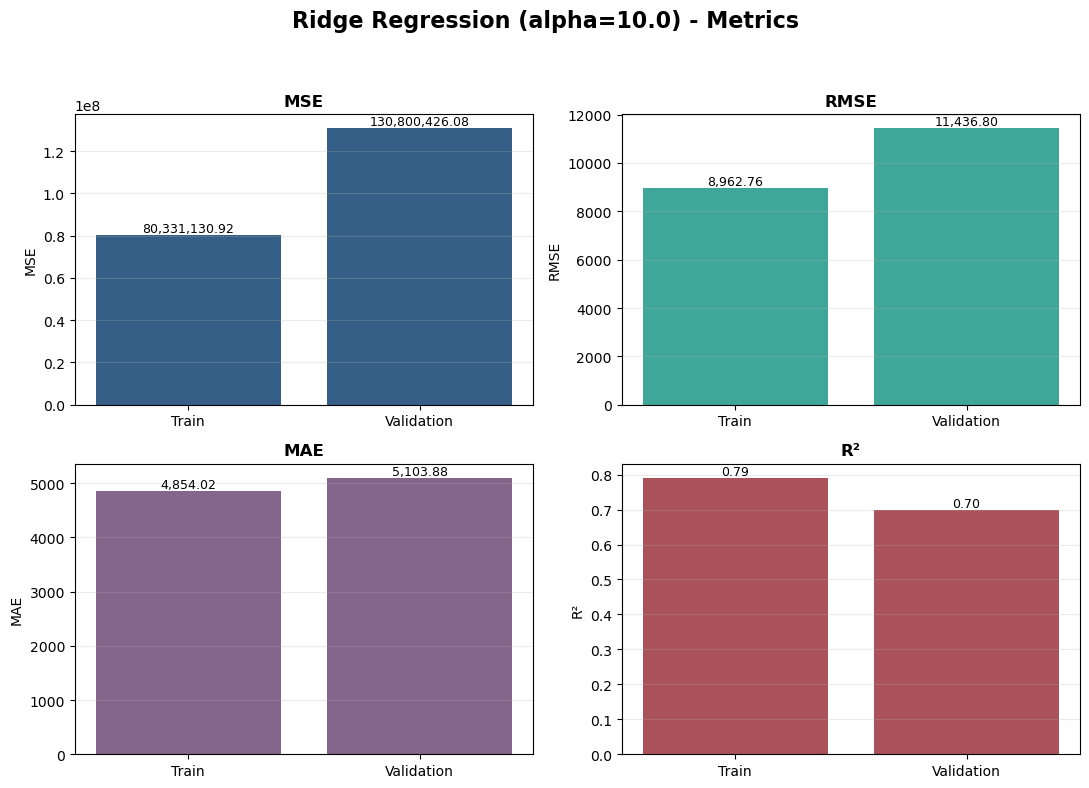

In [40]:
visual.plot_regression_metrics(
    ridge_metrics,
    model_name=f"Ridge Regression (alpha={best_ridge_alpha})"
)

### Ridge Regression: análisis del resultado

Ridge Regression se incorporó como una extensión de la regresión lineal con regularización L2. El objetivo de este modelo es penalizar coeficientes demasiado grandes para reducir el riesgo de overfitting, especialmente cuando existen muchas variables predictoras o alta multicolinealidad entre ellas.

Sin embargo, en este caso Ridge no produjo una mejora significativa respecto de la regresión lineal. Esto puede explicarse porque, aunque el dataset tiene muchas variables luego del One-Hot Encoding, la cantidad de observaciones es suficientemente grande en relación con la cantidad de features. Por lo tanto, el modelo lineal ya se encuentra relativamente bien determinado y no parece estar sufriendo un sobreajuste severo.

Al evaluar distintos valores de `alpha`, las métricas obtenidas fueron muy similares entre sí. Esto indica que aumentar la intensidad de la regularización no mejora de forma relevante la capacidad predictiva del modelo. En otras palabras, penalizar más los coeficientes no reduce sustancialmente el error de validación.

Por este motivo, se seleccionó el valor de `alpha` que obtuvo el menor MSE, aunque la diferencia con otros valores fue pequeña. Este resultado sugiere que, para este problema, Ridge Regression funciona principalmente como una confirmación de que la regresión lineal simple ya constituye una baseline estable.

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
LASSO Regression
</h3>

In [41]:
# ALPHAS = (0.001, 0.01, 0.1, 1, 10, 100, 500, 1000)

# best_lasso_alpha, lasso_cv_results = gs.find_best_alpha_lasso(
#     X_train, y_train, alphas=ALPHAS, cv=5,
# )

# print(f"Best Lasso alpha: {best_lasso_alpha}")
# lasso_cv_results

In [42]:
# lasso_model, lasso_metrics, lasso_predictions = mod.train_lasso_regression(
#     X_train, y_train, X_val, y_val, alpha=best_lasso_alpha,
# )
# lasso_metrics

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Random Forest Regressor
</h3>

In [43]:
random_forest_model, random_forest_metrics, random_forest_predictions = mod.train_random_forest(
    X_train_pp,
    y_train,
    X_val_pp,
    y_val,
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
)

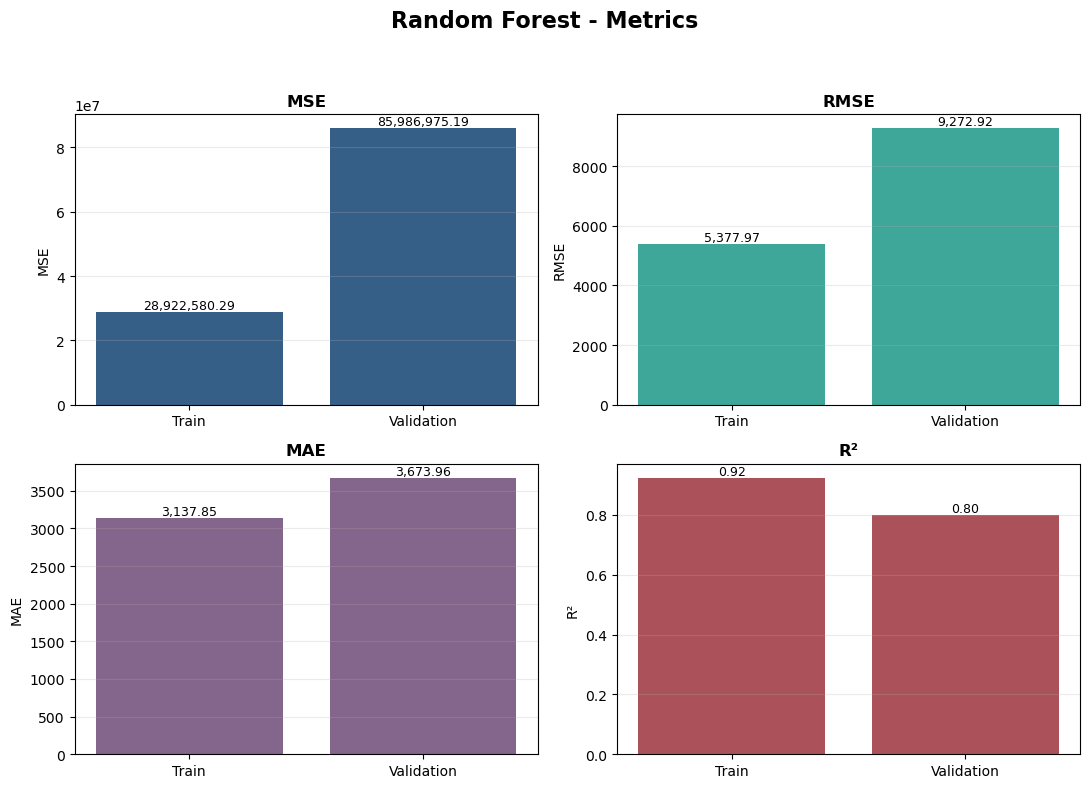

In [44]:
visual.plot_regression_metrics(
    random_forest_metrics,
    model_name=f"Random Forest"
)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
XGBoost
</h3>

In [45]:
xgboost_model, xgboost_metrics, xgboost_predictions = mod.train_xgboost(
    X_train_pp,
    y_train,
    X_val_pp,
    y_val,
    use_log_target=False,
    n_estimators = 500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
)

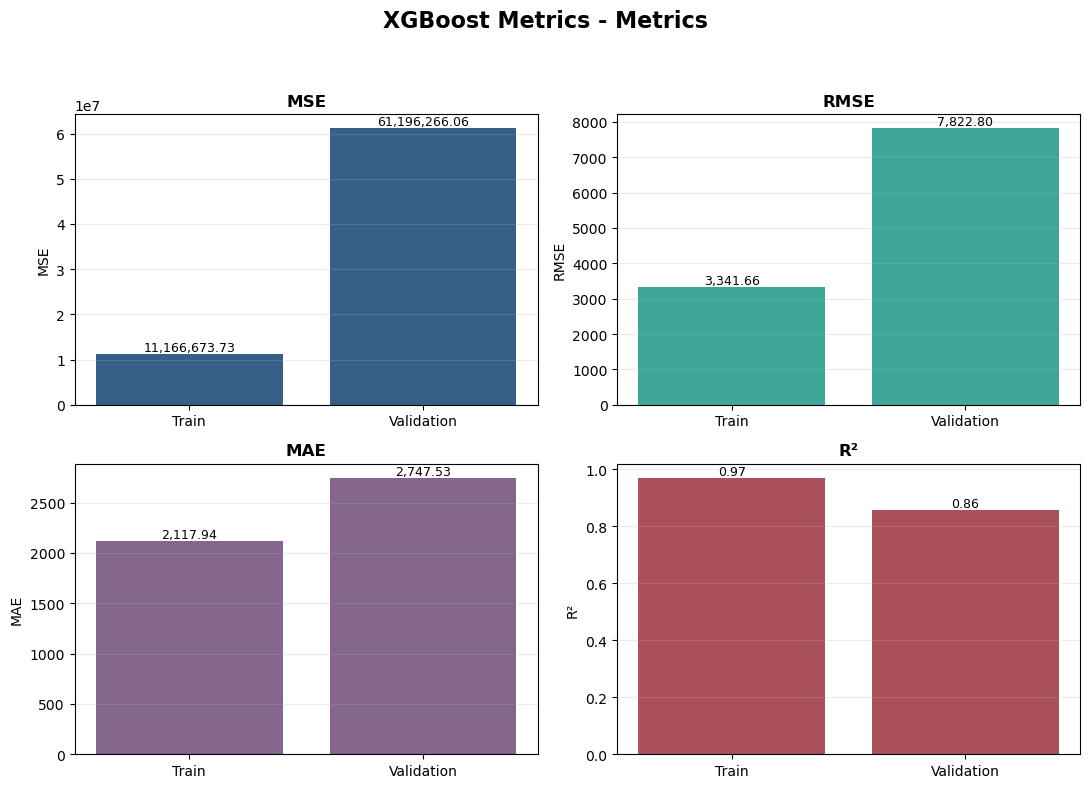

In [46]:
visual.plot_regression_metrics(
    xgboost_metrics,
    model_name="XGBoost Metrics",
)

<h1 style="
    background-color: #d0ebff; 
    color: #1a1a1a; 
    display: inline-block; 
    padding: 10px 18px; 
    border-radius: 10px;
    font-size: 32px;
">
Log target prediction
</h1>

Como vimos en el EDA, la variable `Precio` tiene una distribución bastante sesgada: la mayoría de los autos se concentran en valores medios, pero hay algunos vehículos mucho más caros que estiran la cola derecha de la distribución. Al aplicar logaritmo, la distribución queda más equilibrada y se parece más a una normal.

Por este motivo, además de entrenar modelos usando el precio original en dólares, también probamos entrenarlos sobre `log(Precio)`. Esta transformación ayuda a reducir el peso de los precios extremos y permite que el modelo aprenda mejor relaciones proporcionales. Por ejemplo, un error de 5.000 USD no significa lo mismo para un auto de 10.000 USD que para uno de 100.000 USD.

De todas formas, las métricas finales se calculan nuevamente en la escala original del precio, es decir, en dólares. Así podemos comparar los resultados con los modelos anteriores usando MSE, RMSE, MAE y R² de forma interpretable.

In [47]:
USE_LOG_TARGET = True

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Linear Regression (Log)
</h3>

In [48]:
linear_log_model, linear_log_metrics, linear_log_predictions = mod.train_linear_regression(
    X_train_pp,
    y_train,
    X_val_pp,
    y_val,
    use_log_target=USE_LOG_TARGET,
)

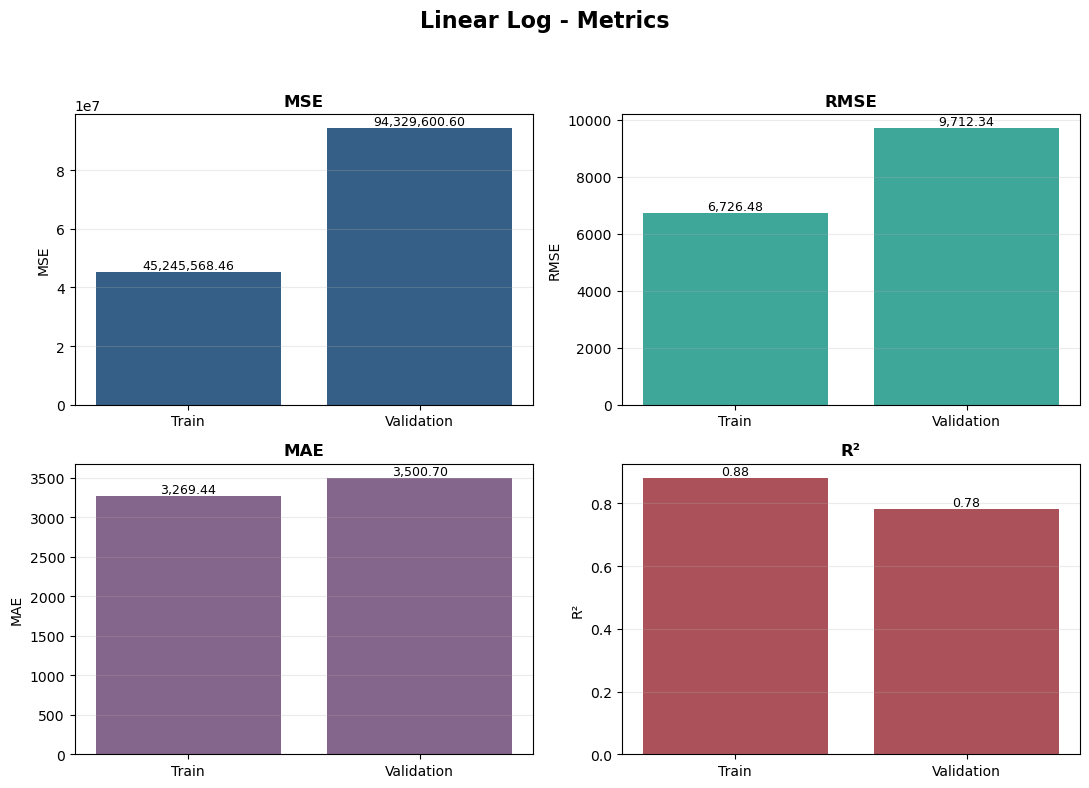

In [49]:
visual.plot_regression_metrics(
    linear_log_metrics,
    model_name=f"Linear Log"
)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Ridge Regression (Log)
</h3>

In [50]:
ridge_log_model, ridge_log_metrics, ridge_log_predictions = mod.train_ridge_regression(
    X_train_pp,
    y_train,
    X_val_pp,
    y_val,
    alpha=best_ridge_alpha,
    use_log_target=True,
)

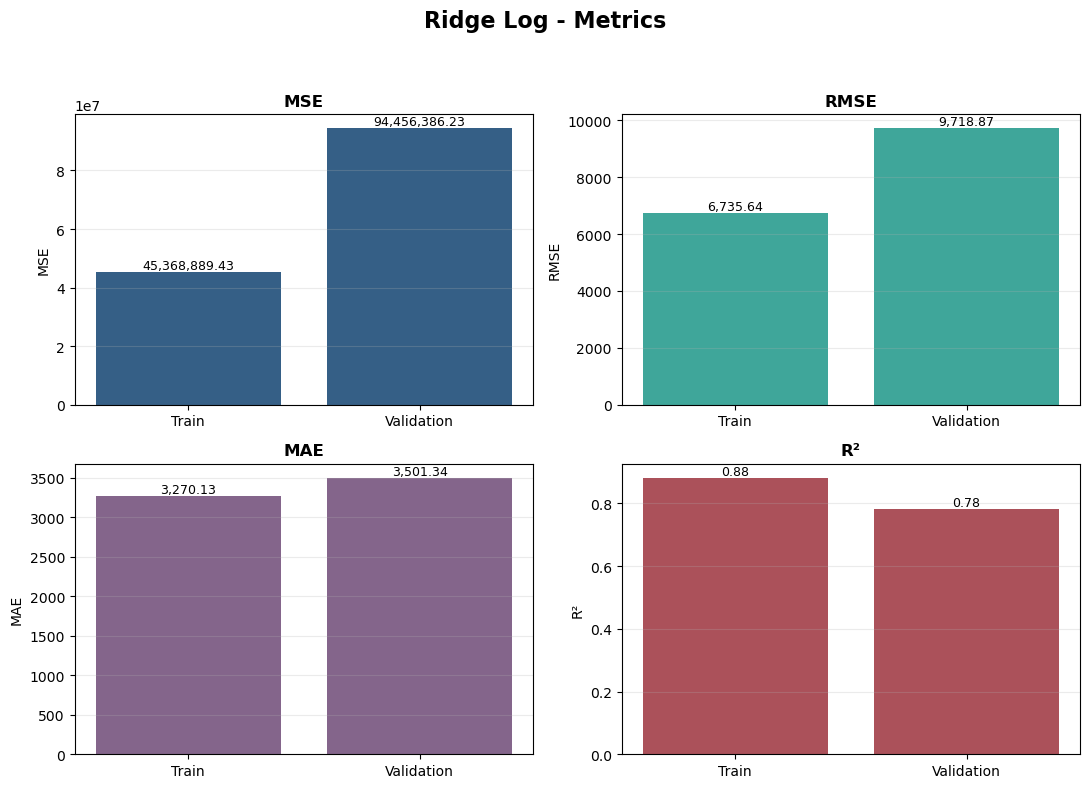

In [51]:
visual.plot_regression_metrics(
    ridge_log_metrics,
    model_name=f"Ridge Log"
)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Random Forest Regressor (Log)
</h3>

In [52]:
random_forest_log_model, random_forest_log_metrics, random_forest_log_predictions = mod.train_random_forest(
    X_train_pp,
    y_train,
    X_val_pp,
    y_val,
    use_log_target = USE_LOG_TARGET,
    n_estimators=300,
    max_depth=None,
    min_samples_leaf = 5,
)

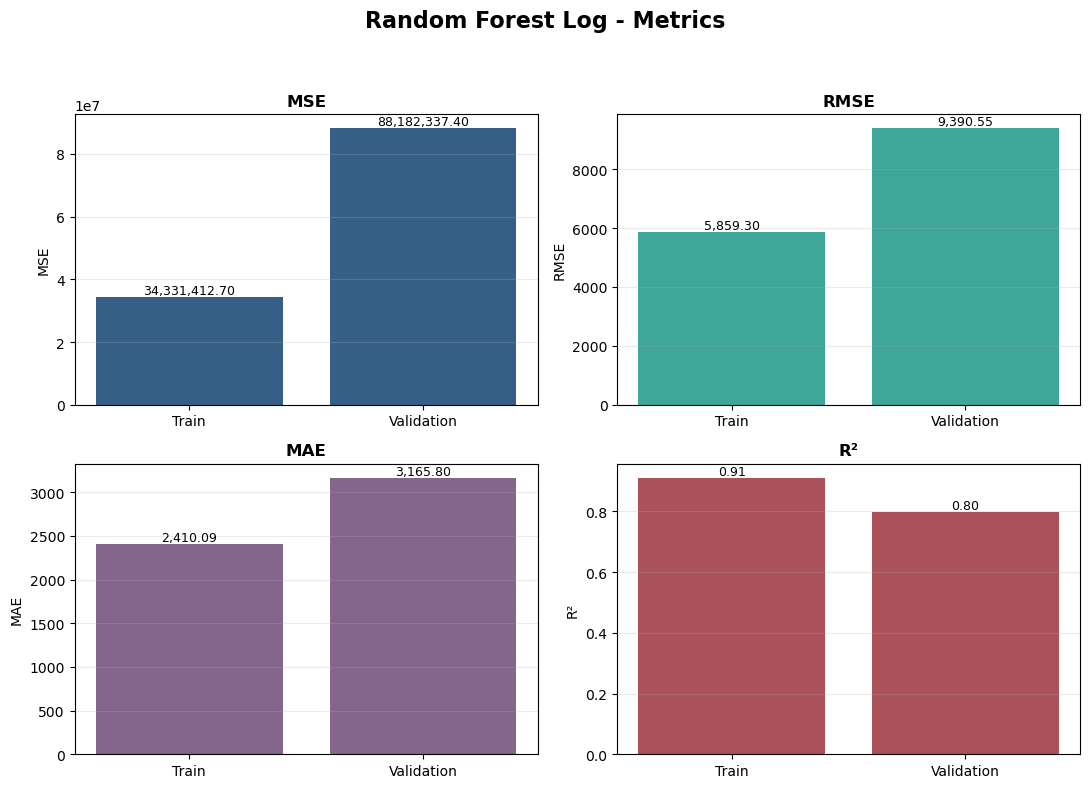

In [53]:
visual.plot_regression_metrics(
    random_forest_log_metrics,
    model_name=f"Random Forest Log"
)

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
Random Forest (Log) - Grid Search
</h3>

In [54]:
RF_PARAM_GRID = {
    "n_estimators": [300, 500],
    "max_depth": [12, 18, 25, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [2, 4, 8, 12],
    "max_features": [0.3, 0.5, 0.7, "sqrt"],
}

In [55]:
RF_PARAM_GRID_REFINED = {
    "n_estimators": [300, 500, 700],
    "max_depth": [6, 8, 10, 12, 14, 16],
    "min_samples_split": [3, 5, 8, 10],
    "min_samples_leaf": [1, 2, 3, 4],
    "max_features": [0.4, 0.5, 0.6],
}

In [56]:
categorical_cols = [
    "Marca",
    "Modelo",
    "Color",
    "Tipo de vendedor",
    "Tipo de combustible",
    "Transmisión"
]

In [57]:
# best_rf_params, rf_cv_results = gs.find_best_random_forest_params(
#     X_train,
#     y_train,
#     param_grid = RF_PARAM_GRID_REFINED,
#     cv = 5,
#     use_log_target=True,
#     scoring = "rmse",
#     categorical_cols = categorical_cols,
#     binary_missing_cols = ["Con cámara de retroceso"],
# )
# rf_cv_results

In [58]:
# best_rf_params

In [59]:
# best_rf_model, best_rf_metrics, best_rf_predictions = mod.train_random_forest(
#     X_train_pp,
#     y_train,
#     X_val_pp,
#     y_val,
#     use_log_target=True,
#     **best_rf_params,
# )

In [60]:
# visual.plot_regression_metrics(
#     best_rf_metrics,
#     model_name=f"Random Forest Log - Grid Search"
# )

<h3 style="background-color: #343a40; color: #ffffff; display: inline-block; padding: 6px 10px; border-radius: 6px;">
XGBoost (Log)
</h3>

In [72]:
xgboost_log_model, xgboost_log_metrics, xgboost_log_predictions = mod.train_xgboost(
    X_train_pp,
    y_train,
    X_val_pp,
    y_val,
    use_log_target=True,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
)


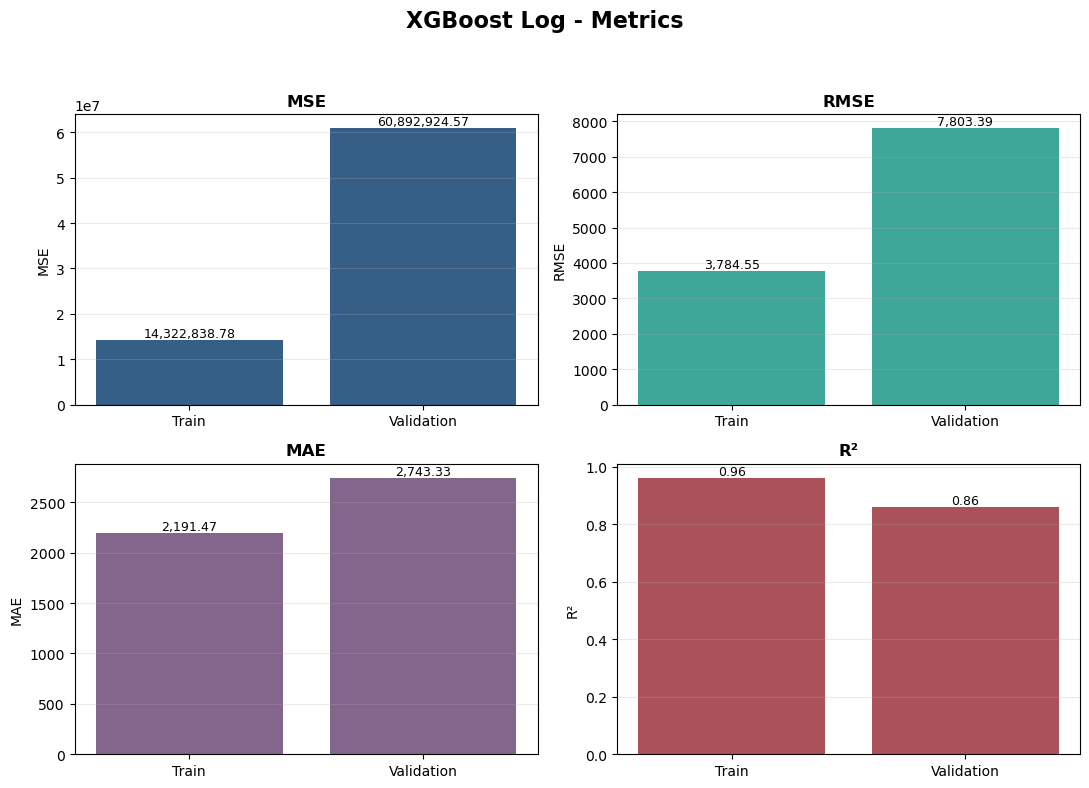

In [62]:
visual.plot_regression_metrics(
    xgboost_log_metrics,
    model_name="XGBoost Log",
)

<h1 style="
    background-color: #d0ebff; 
    color: #1a1a1a; 
    display: inline-block; 
    padding: 10px 18px; 
    border-radius: 10px;
    font-size: 32px;
">
Errors Analysis
</h1>

In [77]:
xgboost_log_error_context = mod.attach_prediction_context(
    xgboost_log_predictions,
    X_train,
    X_val,
)

mod.top_prediction_errors(
    xgboost_log_error_context,
    split="validation",
    n=20,
).style.hide(axis="index")

split,row_index,Marca,Modelo,Año,Kilómetros,Cilindrada,Transmisión,Tipo de combustible,Color,Tipo de vendedor,Con cámara de retroceso,y_true,y_pred,residual,abs_error,signed_pct_error,abs_pct_error
validation,2938,volkswagen,nivus,2024.000000,0,1.000000,automatica,nafta,gris,concesionaria,nan,300460.546515,27842.052734,272618.493781,272618.493781,90.733541,90.733541
validation,3335,porsche,cayenne,2022.000000,14000,4.000000,automatica,nafta,gris,tienda,1.000000,345000.000000,162692.500000,182307.500000,182307.500000,52.842754,52.842754
validation,2516,bmw,x5,2024.000000,11972,3.000000,automatica,nafta,gris,concesionaria,nan,249000.000000,125674.914062,123325.085938,123325.085938,49.528147,49.528147
validation,2723,alfa romeo,stelvio,2024.000000,0,3.000000,automatica,nafta,negro,concesionaria,nan,230000.000000,112872.250000,117127.750000,117127.750000,50.925109,50.925109
validation,1890,bmw,x3,2021.000000,13500,3.000000,automatica,nafta,gris,concesionaria,nan,198000.000000,119909.156250,78090.843750,78090.843750,39.439820,39.439820
validation,651,chevrolet,equinox,2020.000000,87,1.500000,automatica,nafta,blanco,concesionaria,nan,85968.681977,29176.404297,56792.277680,56792.277680,66.061589,66.061589
validation,762,bmw,x3,2019.000000,5000,2.000000,automatica,nafta,azul,particular,nan,133000.000000,77830.570312,55169.429688,55169.429688,41.480774,41.480774
validation,1960,jeep,grand cherokee,2019.000000,47000,6.400000,automatica,nafta,rojo,particular,nan,125000.000000,71168.937500,53831.062500,53831.062500,43.064850,43.064850
validation,2607,bmw,x2,2021.000000,8000,2.000000,automatica,nafta,negro,tienda,nan,103000.000000,60255.960938,42744.039062,42744.039062,41.499067,41.499067
validation,801,bmw,x3,2021.000000,32000,3.000000,automatica,nafta,negro,particular,nan,70000.000000,112010.953125,-42010.953125,42010.953125,-60.015647,60.015647


In [ ]:
mod.summarize_prediction_errors(
    xgboost_log_error_context,
    group_cols="Marca",
    split="validation",
    min_count=20,
)

,Marca,count,mae,median_abs_error,rmse,mean_residual,median_y_true,median_y_pred,mean_abs_pct_error,bias_direction
0,mercedes benz,56,8542.860125,4948.599609,12372.502988,4431.762120,53750.000000,53925.986328,13.739841,underprediction
1,bmw,134,7882.575411,3620.127930,16794.986048,1533.065877,42900.000000,44912.082031,11.852876,underprediction
2,audi,106,5438.669355,3263.943359,8602.724648,-472.903627,38700.000000,39590.703125,9.711633,overprediction
3,fiat,73,3629.383959,2907.582969,4848.368319,454.767432,23211.544366,22311.349609,20.804096,underprediction
4,volkswagen,407,3361.948085,2146.266904,14015.518228,1037.866226,29057.414799,28009.093750,10.939301,underprediction
5,toyota,251,3135.919802,2211.016490,5562.536028,1146.780213,37396.377034,38525.406250,7.771609,underprediction
6,jeep,409,2835.095290,1876.772650,4858.750110,313.950410,30862.757138,31872.789062,9.188549,underprediction
7,peugeot,250,2352.383050,1298.029234,3625.153998,109.099079,19076.880565,18477.669922,11.400307,underprediction
8,baic,33,2301.295839,1154.357422,3874.641956,1590.343010,37900.000000,37059.378906,6.286099,underprediction
9,hyundai,114,2232.864972,1515.646484,3400.099601,-76.125980,22953.638317,23362.035156,10.780176,overprediction


SEPARO EN ALTA GAMA Y PRUEBO

In [85]:
high_end_brands = [
    "Marca_alfa romeo",
    "Marca_audi",
    "Marca_bmw",
    "Marca_ds",
    "Marca_jaguar",
    "Marca_land rover",
    "Marca_lexus",
    "Marca_mercedes benz",
    "Marca_mini",
    "Marca_porsche",
    "Marca_volvo",
]

In [94]:
high_end_mask_train = X_train_pp[high_end_brands].any(axis=1)
high_end_mask_val = X_val_pp[high_end_brands].any(axis=1)

In [95]:
X_train_high_end = X_train_pp[high_end_mask_train]
X_train_rest = X_train_pp[~high_end_mask_train]
y_train_high_end = y_train[high_end_mask_train]
y_train_rest = y_train[~high_end_mask_train]

In [96]:
X_val_high_end = X_val_pp[high_end_mask_val]
X_val_rest = X_val_pp[~high_end_mask_val]
y_val_high_end = y_val[high_end_mask_val]
y_val_rest = y_val[~high_end_mask_val]

In [97]:
xgboost_log_model, xgboost_log_metrics, xgboost_log_predictions = mod.train_xgboost(
    X_train_rest,
    y_train_rest,
    X_val_rest,
    y_val_rest,
    use_log_target=True,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
)

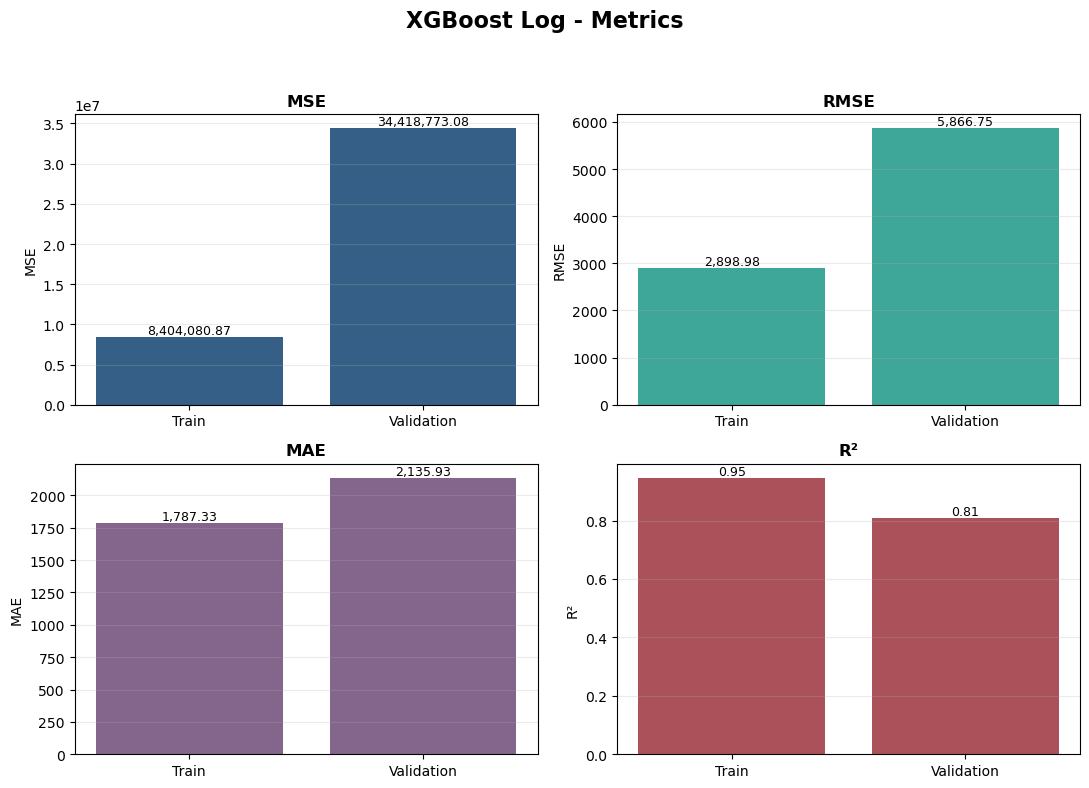

In [98]:
visual.plot_regression_metrics(
    xgboost_log_metrics,
    model_name="XGBoost Log",
)

In [99]:
xgboost_log_model, xgboost_log_metrics, xgboost_log_predictions = mod.train_xgboost(
    X_train_high_end,
    y_train_high_end,
    X_val_high_end,
    y_val_high_end,
    use_log_target=True,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
)

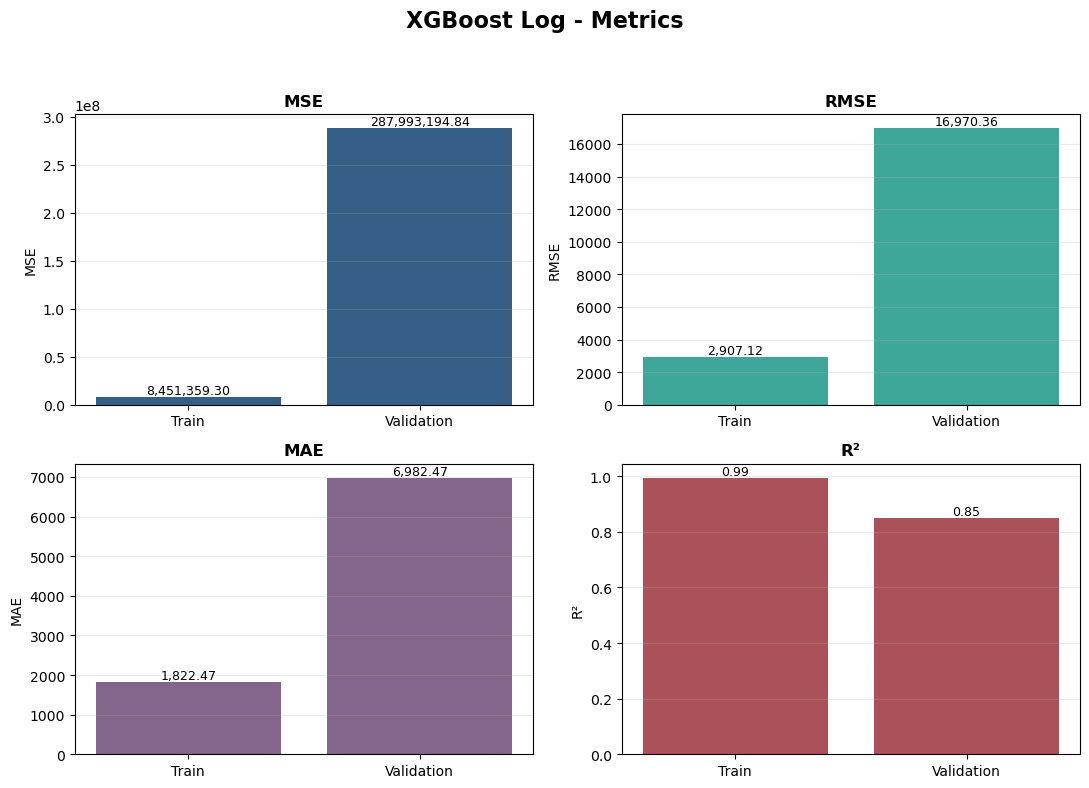

In [100]:
visual.plot_regression_metrics(
    xgboost_log_metrics,
    model_name="XGBoost Log",
)